<a href="https://colab.research.google.com/github/thusharshetty1906-a11y/Garbage-Classification/blob/main/dl_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import zipfile

zip_path = "/content/Garbage classification.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
import os

In [ ]:
print(os.listdir("/content"))
print(os.listdir("/content/Garbage classification"))

['.config', 'Garbage classification', 'Garbage classification.zip', 'sample_data']
['metal', 'trash', 'glass', 'paper', 'cardboard', 'plastic']


In [ ]:
dataset_path = "/content/Garbage classification"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2,
    brightness_range=[0.8,1.2]
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Class Labels:", train_data.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Class Labels: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.2836 - loss: 1.6412 - val_accuracy: 0.3260 - val_loss: 1.6338
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.3671 - loss: 1.4973 - val_accuracy: 0.3817 - val_loss: 1.5011
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.4501 - loss: 1.3413 - val_accuracy: 0.4294 - val_loss: 1.4753
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.5064 - loss: 1.2559 - val_accuracy: 0.4771 - val_loss: 1.3659
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.5361 - loss: 1.2225 - val_accuracy: 0.4533 - val_loss: 1.3881
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.5568 - loss: 1.1601 - val_accuracy: 0.4612 - val_loss: 1.3946
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.5889 - loss: 1.0867 - val_accuracy: 0.5129 - val_loss: 1.2619
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.6097 - loss: 1.0643 - val_accuracy: 0.5268 - v

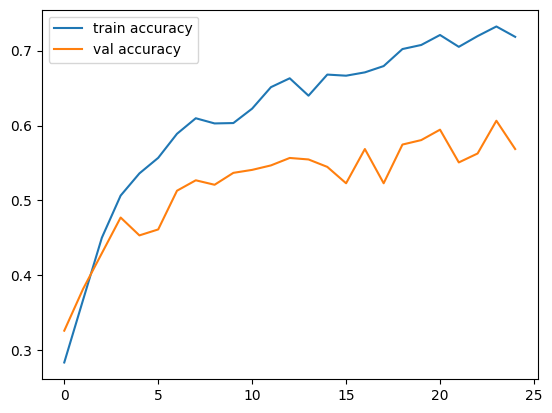

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

In [ ]:
img_path = "/content/metal14.jpg"  # change to your image name

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Prediction:", class_names[np.argmax(prediction)])
print("Confidence:", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Prediction: metal
Confidence: 0.8225446


In [ ]:
img_path = "/content/paper6.jpg"  # change to your image name

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Prediction:", class_names[np.argmax(prediction)])
print("Confidence:", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: paper
Confidence: 0.9613497


In [ ]:
img_path = "/content/test.jpg"  # change to your image name

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Prediction:", class_names[np.argmax(prediction)])
print("Confidence:", np.max(prediction))

In [ ]:
img_path = "/content/cardboard14.jpg"  # change to your image name

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Prediction:", class_names[np.argmax(prediction)])
print("Confidence:", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: cardboard
Confidence: 0.90863615
